In [1]:
import re
import pandas as pd
import numpy as np
# from dython.nominal import associations
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_parquet('/content/drive/MyDrive/final/AB추출.parquet')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Columns: 858 entries, 기준년월 to 이용금액대
dtypes: float64(61), int64(747), object(50)
memory usage: 7.3+ MB


In [7]:
df.select_dtypes(include='object')

,ID,연령,Segment,가입통신회사코드,거주시도명,직장시도명,_1순위신용체크구분,_2순위신용체크구분,연회비발생카드수_B0M,상품관련면제카드수_B0M,...,_2순위교통업종,_3순위교통업종,_1순위여유업종,_2순위여유업종,_3순위여유업종,_1순위납부업종,_2순위납부업종,_3순위납부업종,최종카드론_신청경로코드,이용금액대
0,TRAIN_002898,40대,A,S사,경기,경기,신용,None,0개,0개,...,택시,None,None,None,None,납부기타,None,None,8,01.100만원+
1,TRAIN_005253,50대,A,S사,부산,부산,신용,신용,0개,0개,...,정비,None,None,None,None,납부기타,None,None,1,01.100만원+
2,TRAIN_008128,40대,A,K사,경기,경기,신용,신용,0개,0개,...,버스지하철,정비,공연,None,None,통신비,납부기타,None,None,01.100만원+
3,TRAIN_010808,40대,A,K사,경기,경기,신용,신용,0개,0개,...,정비,택시,None,None,None,통신비,None,None,None,01.100만원+
4,TRAIN_014951,30대,A,None,서울,서울,신용,None,0개,0개,...,택시,버스지하철,운동,여유기타,None,None,None,None,None,01.100만원+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,TRAIN_376373,40대,A,S사,경기,경기,신용,None,0개,0개,...,정비,택시,운동,None,None,통신비,납부기타,None,None,01.100만원+
1112,TRAIN_378479,50대,A,S사,서울,서울,신용,신용,0개,0개,...,정비,철도버스,운동,숙박,공연,보험료,통신비,납부기타,None,01.100만원+
1113,TRAIN_390620,50대,B,S사,서울,서울,신용,체크,0개,0개,...,None,None,None,None,None,보험료,None,None,8,01.100만원+
1114,TRAIN_393027,40대,A,S사,서울,서울,신용,신용,0개,0개,...,정비,택시,운동,None,None,납부기타,None,None,None,01.100만원+


In [9]:
df.select_dtypes(include='object').columns

Index(['ID', '연령', 'Segment', '가입통신회사코드', '거주시도명', '직장시도명', '_1순위신용체크구분',
       '_2순위신용체크구분', '연회비발생카드수_B0M', '상품관련면제카드수_B0M', '임직원면제카드수_B0M',
       '우수회원면제카드수_B0M', '기타면제카드수_B0M', 'Life_Stage', '자발한도감액횟수_R12M',
       '한도증액횟수_R12M', '카드론동의여부', 'RV전환가능여부', '한도심사요청건수', '대표결제방법코드',
       '대표청구지고객주소구분코드', '대표청구서수령지구분코드', '청구서수령방법', '할인건수_R3M', '할인건수_B0M',
       '인입횟수_ARS_R6M', '이용메뉴건수_ARS_R6M', '방문횟수_PC_R6M', '방문일수_PC_R6M',
       '방문횟수_앱_R6M', 'OS구분코드', '캠페인접촉건수_R12M', '캠페인접촉일수_R12M', '_1순위업종',
       '_2순위업종', '_3순위업종', '_1순위쇼핑업종', '_2순위쇼핑업종', '_3순위쇼핑업종', '_1순위교통업종',
       '_2순위교통업종', '_3순위교통업종', '_1순위여유업종', '_2순위여유업종', '_3순위여유업종', '_1순위납부업종',
       '_2순위납부업종', '_3순위납부업종', '최종카드론_신청경로코드', '이용금액대'],
      dtype='object')

In [10]:
na_counts = df.isna().sum()
na_cols = na_counts[na_counts >0]
print(na_cols)

가입통신회사코드            79
직장시도명               17
_2순위신용체크구분         234
최종유효년월_신용_이용         7
RV신청일자             889
연체일자_B0M          1116
OS구분코드             474
혜택수혜율_R3M            9
혜택수혜율_B0M           13
_1순위업종              22
_2순위업종              39
_3순위업종              62
_1순위쇼핑업종            45
_2순위쇼핑업종            71
_3순위쇼핑업종            99
_1순위교통업종           101
_2순위교통업종           216
_3순위교통업종           436
_1순위여유업종           326
_2순위여유업종           636
_3순위여유업종           863
_1순위납부업종           189
_2순위납부업종           550
_3순위납부업종           892
최종카드론_금융상환방식코드     642
최종카드론_신청경로코드       644
최종카드론_대출일자         768
dtype: int64


In [11]:
# 결측치 27개
len(na_cols)

27

- 상관계수를 구하기 위해 결측치가 있는 모든 컬럼은 제거한다.

In [12]:
df = df.dropna(axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Columns: 831 entries, 기준년월 to 이용금액대
dtypes: float64(54), int64(747), object(30)
memory usage: 7.1+ MB


In [13]:
df.select_dtypes(include='object')

,ID,연령,Segment,거주시도명,_1순위신용체크구분,연회비발생카드수_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,...,할인건수_R3M,할인건수_B0M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M,방문횟수_PC_R6M,방문일수_PC_R6M,방문횟수_앱_R6M,캠페인접촉건수_R12M,캠페인접촉일수_R12M,이용금액대
0,TRAIN_002898,40대,A,경기,신용,0개,0개,0개,0개,0개,...,1회 이상,1회 이상,10회 이상,10회 이상,1회 이상,1회 이상,1회 이상,5회 이상,5일 이상,01.100만원+
1,TRAIN_005253,50대,A,부산,신용,0개,0개,0개,0개,0개,...,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1일 이상,01.100만원+
2,TRAIN_008128,40대,A,경기,신용,0개,0개,0개,0개,0개,...,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1일 이상,01.100만원+
3,TRAIN_010808,40대,A,경기,신용,0개,0개,0개,0개,0개,...,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,5회 이상,5일 이상,01.100만원+
4,TRAIN_014951,30대,A,서울,신용,0개,0개,0개,0개,0개,...,1회 이상,1회 이상,1회 이상,1회 이상,30회 이상,20회 이상,1회 이상,1회 이상,1일 이상,01.100만원+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,TRAIN_376373,40대,A,경기,신용,0개,0개,0개,0개,0개,...,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,1회 이상,1일 이상,01.100만원+
1112,TRAIN_378479,50대,A,서울,신용,0개,0개,0개,0개,0개,...,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1일 이상,01.100만원+
1113,TRAIN_390620,50대,B,서울,신용,0개,0개,0개,0개,0개,...,1회 이상,1회 이상,10회 이상,30회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1일 이상,01.100만원+
1114,TRAIN_393027,40대,A,서울,신용,0개,0개,0개,0개,0개,...,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10일 이상,01.100만원+


In [14]:
# object 타입 컬럼만 추출
obj_cols = df.select_dtypes(include='object').columns

In [15]:
obj_cols

Index(['ID', '연령', 'Segment', '거주시도명', '_1순위신용체크구분', '연회비발생카드수_B0M',
       '상품관련면제카드수_B0M', '임직원면제카드수_B0M', '우수회원면제카드수_B0M', '기타면제카드수_B0M',
       'Life_Stage', '자발한도감액횟수_R12M', '한도증액횟수_R12M', '카드론동의여부', 'RV전환가능여부',
       '한도심사요청건수', '대표결제방법코드', '대표청구지고객주소구분코드', '대표청구서수령지구분코드', '청구서수령방법',
       '할인건수_R3M', '할인건수_B0M', '인입횟수_ARS_R6M', '이용메뉴건수_ARS_R6M', '방문횟수_PC_R6M',
       '방문일수_PC_R6M', '방문횟수_앱_R6M', '캠페인접촉건수_R12M', '캠페인접촉일수_R12M', '이용금액대'],
      dtype='object')

In [16]:
# 복사본 생성
df_cleaned = df.copy()

for col in obj_cols:
    sample_values = df_cleaned[col].dropna().astype(str).unique()
    example = sample_values[0]

    # "30대", "40대" 등 연령 처리
    if all(re.fullmatch(r'\d+대', v) for v in sample_values):
        df_cleaned[col] = df_cleaned[col].str.replace("대", "").astype(int)

    # "0개", "1개" 등 개수 처리
    elif all(re.fullmatch(r'\d+개', v) for v in sample_values):
        df_cleaned[col] = df_cleaned[col].str.replace("개", "").astype(int)

    # "10회 이상", "1회 이상" 등 처리
    elif all(re.fullmatch(r'\d+회 이상', v) for v in sample_values):
        df_cleaned[col] = df_cleaned[col].str.extract(r'(\d+)').astype(int)

    # "1일 이상", "10일 이상" 등 처리
    elif all(re.fullmatch(r'\d+일 이상', v) for v in sample_values):
        df_cleaned[col] = df_cleaned[col].str.extract(r'(\d+)').astype(int)

    # "01.100만원+" 등 이용금액대 처리
    elif all(re.fullmatch(r'\d{2}\.\d+만원\+', v) for v in sample_values):
        # 앞의 번호를 숫자로 추출 (01 → 1, 02 → 2 ...)
        df_cleaned[col] = df_cleaned[col].str.extract(r'(\d{2})').astype(int)

    # Segment나 기타 범주형 문자열 (A/B/C...) → 레이블 인코딩
    elif all(re.fullmatch(r'[A-Z]', v) for v in sample_values):
        df_cleaned[col] = df_cleaned[col].astype('category').cat.codes

    # 지역명, 신용/체크 등 기타 텍스트도 레이블 인코딩 처리
    else:
        df_cleaned[col] = df_cleaned[col].astype('category').cat.codes

print("변환 완료")

변환 완료


In [17]:
df_cleaned[col].astype('category').cat.categories

Index([1], dtype='int64')

In [18]:
df['연령'] = df['연령'].astype('category')
print(dict(enumerate(df['연령'].cat.categories)))

{0: '20대', 1: '30대', 2: '40대', 3: '50대', 4: '60대', 5: '70대이상'}


In [19]:
df['거주시도명'] = df['거주시도명'].astype('category')
print(df['거주시도명'].cat.categories)

Index(['강원', '경기', '경남', '경북', '광주', '대구', '대전', '부산', '서울', '울산', '인천', '전남',
       '전북', '충남', '충북'],
      dtype='object')


| 거주시도명 | 코드 |
|------------|------|
| 강원       | 0    |
| 경기       | 1    |
| 경남       | 2    |
| 경북       | 3    |
| 광주       | 4    |
| 대구       | 5    |
| 대전       | 6    |
| 부산       | 7    |
| 서울       | 8    |
| 울산       | 9    |
| 인천       | 10   |
| 전남       | 11   |
| 전북       | 12   |
| 충남       | 13   |
| 충북       | 14   |

In [20]:
# # LabelEncoder 하기

# obj_cols = df.select_dtypes(include='object').columns

# le_dict = {}

# for col in obj_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col].astype(str))
#     le_dict[col] = le

# df.info()

In [21]:
# 현재 설정된 폰트 확인
print("현재 설정된 폰트:", plt.rcParams['font.family'])

현재 설정된 폰트: ['NanumGothic']


/tmp/ipython-input-24-3926391682.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


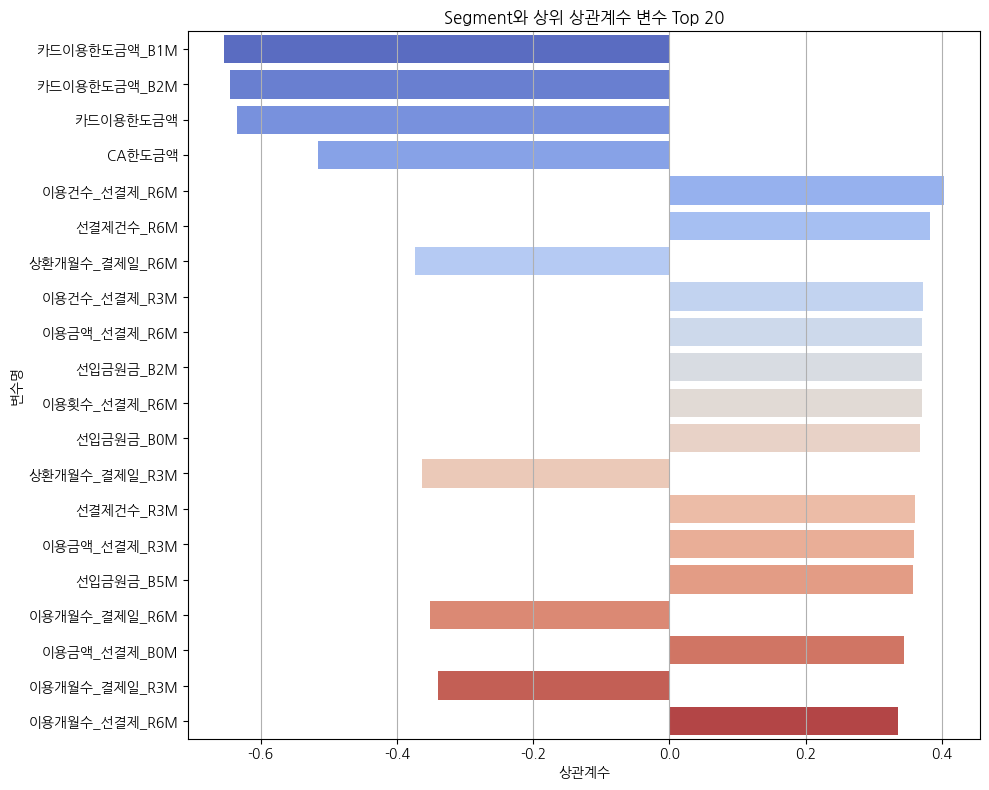

In [24]:
# 상관계수 계산
segment_corr = df_cleaned.corr(numeric_only=True)['Segment'].sort_values(key=abs, ascending=False)

# Segment 제외하고 상관계수 상위 20개 추출
top_corr = segment_corr.drop('Segment').head(20)

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title("Segment와 상위 상관계수 변수 Top 20")
plt.xlabel("상관계수")
plt.ylabel("변수명")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [6]:
segment_corr = pd.read_csv('/content/drive/MyDrive/final/Segment_상관계수_정리.csv')
print(segment_corr)

            Unnamed: 0       Segment
0         카드이용한도금액_B1M -6.535542e-01
1         카드이용한도금액_B2M -6.455872e-01
2             카드이용한도금액 -6.350689e-01
3               CA한도금액 -5.159384e-01
4         이용건수_선결제_R6M  4.028849e-01
..                 ...           ...
638  최대이용금액_부분무이자_R12M -3.466678e-04
639       이용개월수_전체_R6M  3.345324e-04
640    신청건수_ATM_CA_R6M -2.762536e-04
641        RV_최대잔액_R6M -1.891012e-04
642               기준년월 -6.755439e-14

[643 rows x 2 columns]


In [26]:
# Segment 자기 자신과 NaN 제거
segment_corr_cleaned = segment_corr.drop(labels='Segment').dropna()

# CSV로 저장
segment_corr_cleaned.to_csv("/content/drive/MyDrive/final/Segment_상관계수_정리.csv", encoding='utf-8-sig', header=True)

#### 처음에 민정님이 계산한 상관관계

In [ ]:
correlations = df.corr()["Segment"].sort_values(ascending=False)

In [ ]:
significant_corr = correlations[correlations.abs() >= 0.3]
significant_corr_sorted = significant_corr.reindex(significant_corr.abs().sort_values(ascending=False).index)

print(significant_corr_sorted)

Segment           1.000000
카드이용한도금액_B1M     -0.653554
카드이용한도금액_B2M     -0.645587
카드이용한도금액         -0.635069
CA한도금액           -0.515938
이용건수_선결제_R6M      0.402885
선결제건수_R6M         0.382041
상환개월수_결제일_R6M    -0.373127
이용건수_선결제_R3M      0.372249
이용금액_선결제_R6M      0.371204
선입금원금_B2M         0.370902
이용횟수_선결제_R6M      0.370574
선입금원금_B0M         0.368353
상환개월수_결제일_R3M    -0.363593
선결제건수_R3M         0.360349
이용금액_선결제_R3M      0.358689
선입금원금_B5M         0.356789
이용개월수_결제일_R6M    -0.351421
이용금액_선결제_B0M      0.344880
이용개월수_결제일_R3M    -0.339004
이용개월수_선결제_R6M     0.334713
이용건수_선결제_B0M      0.327774
이용횟수_선결제_R3M      0.327618
방문일수_앱_R6M        0.313763
홈페이지_선결제건수_R6M    0.305680
방문일수_앱_B0M        0.305060
이용횟수_선결제_B0M      0.300596
Name: Segment, dtype: float64


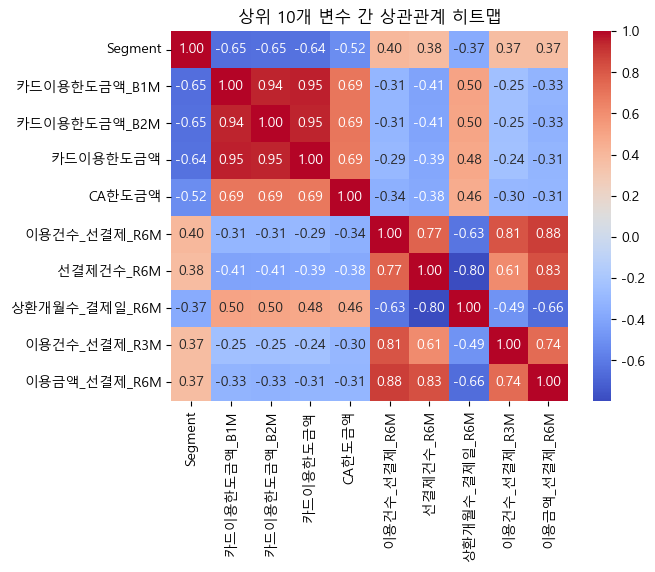

In [ ]:
# Segment와 관련 있는 상위 10개 변수만 선택
top_features = correlations.abs().sort_values(ascending=False).head(10).index
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상위 10개 변수 간 상관관계 히트맵")
plt.show()